## Notebook for explaining the simple equations predicting savings from flexible operations

Explanation is in the outline document. Here the functions can be defined and some useful plots can be made

In [110]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [111]:
# Define the savings function
def calculate_monthly_savings(power_capacity, plant_chars, electricity_rate):
    
    power_capacity = np.asarray(power_capacity, dtype=float)
    total_hrs = 30 * 24 # Assuming 30 days = one month
    num_off_peak_hrs = total_hrs - electricity_rate['num_peak_hrs']
    water_vol_shift = power_capacity * electricity_rate['num_peak_hrs'] / plant_chars['SEC']  # Volume of water that can be shifted to off-peak hours
    # energy_consumption_base = plant_chars['power_base'] * total_hrs
    energy_capacity = power_capacity * electricity_rate['num_peak_hrs']

    condition = water_vol_shift / (plant_chars['Q_perm_max'] - plant_chars['Q_perm_base']) < num_off_peak_hrs
    time_shift = np.where(
        condition,
        num_off_peak_hrs,
        energy_capacity / (plant_chars['SEC'] * plant_chars['Q_perm_min'])
    )

    off_peak_power_increase = energy_capacity / time_shift

    savings = power_capacity * electricity_rate['peak_demand_cost'] - off_peak_power_increase * electricity_rate['off_peak_demand_cost'] + energy_capacity * (electricity_rate['peak_consumption_cost'] - electricity_rate['off_peak_consumption_cost'])
    return savings

In [112]:
#Define a function giving range of power capacities achievable for varying the flowrate
def var_flow_power_cap_range(plant_chars):
    Q_perm_min = plant_chars['Q_min_brine'] * plant_chars['recovery'] / (1 - plant_chars['recovery'])
    power_capacity = Q_perm_min * plant_chars['SEC']
    return power_capacity

In [113]:
# Define a function for the additional brine costs associated with lower recovery rates
def additional_brine_costs(plant_chars):
    #TODO: Implement this if it seems relevant to include in the analysis
    return 0

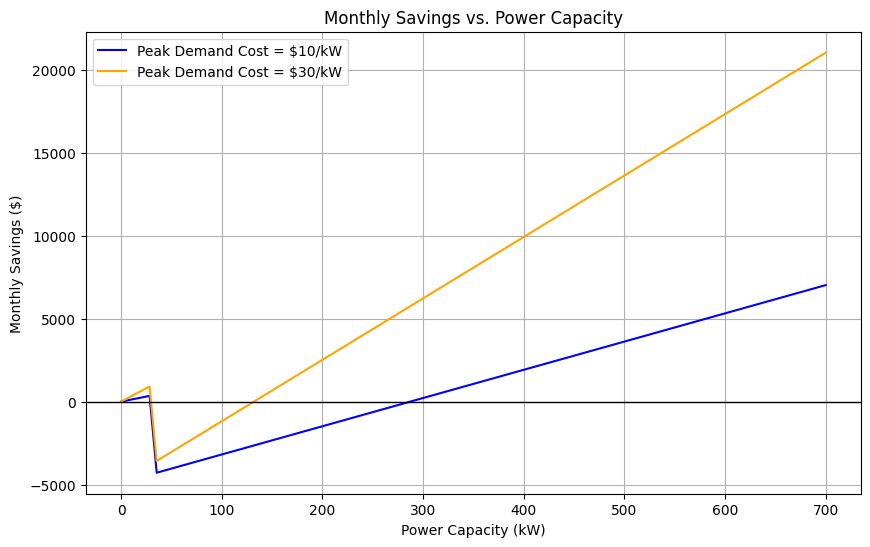

In [114]:
# Define the plant characteristics for # 0.925 RR
wrd_plant_chars = {'SEC':0.44, 'Q_perm_min': 600 * 0.925, 'power_base': 1102, 'Q_perm_base': 605 * 0.925, 'Q_perm_max': 625 * 0.925, 'recovery': 0.925, 'Q_min_brine': 45}

# Plot the savings for two different peak demand costs
sample_week_1_rate = {'num_peak_hrs': 35*4, 'peak_demand_cost': 10, 'off_peak_demand_cost': 20, 'peak_consumption_cost': 0.15, 'off_peak_consumption_cost': 0.10}
sample_week_2_rate = {'num_peak_hrs': 35*4, 'peak_demand_cost': 30, 'off_peak_demand_cost': 20, 'peak_consumption_cost': 0.15, 'off_peak_consumption_cost': 0.10}

x = np.linspace(0, 700, 100)
y1 = calculate_monthly_savings(x, wrd_plant_chars, sample_week_1_rate)
y2 = calculate_monthly_savings(x, wrd_plant_chars, sample_week_2_rate)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Peak Demand Cost = $10/kW', color='blue')
plt.plot(x, y2, label='Peak Demand Cost = $30/kW', color='orange')
plt.title('Monthly Savings vs. Power Capacity')
plt.xlabel('Power Capacity (kW)')
plt.ylabel('Monthly Savings ($)')
plt.legend()
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.grid(True)
plt.show()

5290.6695
-1763.9580000000008


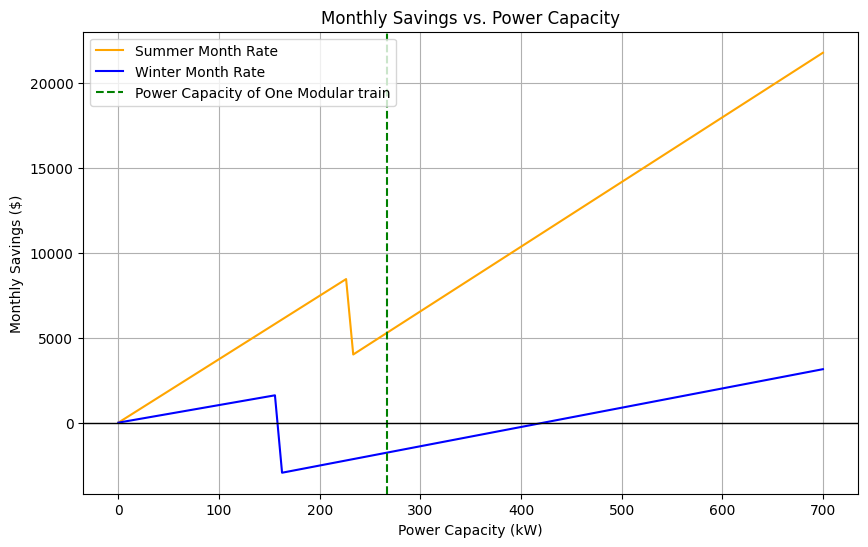

In [115]:
# Plot the savings for summer and winter rates
summer_weekly_rate = {'num_peak_hrs': 25, 'peak_demand_cost': 36.78, 'off_peak_demand_cost': 19.94, 'peak_consumption_cost': 0.1525, 'off_peak_consumption_cost': 0.1016}
winter_weekly_rate = {'num_peak_hrs': 35, 'peak_demand_cost': 10.54, 'off_peak_demand_cost': 19.62, 'peak_consumption_cost': 0.1157, 'off_peak_consumption_cost': 0.0929}

print(calculate_monthly_savings(267, wrd_plant_chars, summer_weekly_rate))
print(calculate_monthly_savings(267, wrd_plant_chars, winter_weekly_rate))

x = np.linspace(0, 700, 100)
y1 = calculate_monthly_savings(x, wrd_plant_chars, summer_weekly_rate)
y2 = calculate_monthly_savings(x, wrd_plant_chars, winter_weekly_rate)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Summer Month Rate', color='orange')
plt.plot(x, y2, label='Winter Month Rate', color='blue')
plt.axvline(267, color='green', linestyle='--', label='Power Capacity of One Modular train')
plt.title('Monthly Savings vs. Power Capacity')
plt.xlabel('Power Capacity (kW)')
plt.ylabel('Monthly Savings ($)')
plt.legend()
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.grid(True)
plt.savefig('monthly_savings_plot.png', dpi=300)

